In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data_path = "/content/USA_Housing.csv"
df = pd.read_csv(data_path)

Exploratory Data Analysis

Load and inspect data

In [ ]:
print(f"Shape: {df.shape}")

Shape: (5000, 7)


In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
df.dtypes

,0
Avg. Area Income,float64
Avg. Area House Age,float64
Avg. Area Number of Rooms,float64
Avg. Area Number of Bedrooms,float64
Area Population,float64
Price,float64
Address,object


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

**Distribution of house prices (histogram)**

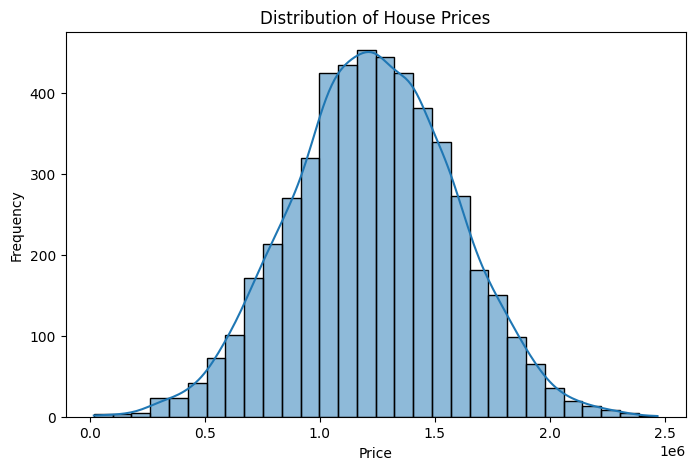

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Feature distributions – Visualize distribution of all numerical features**

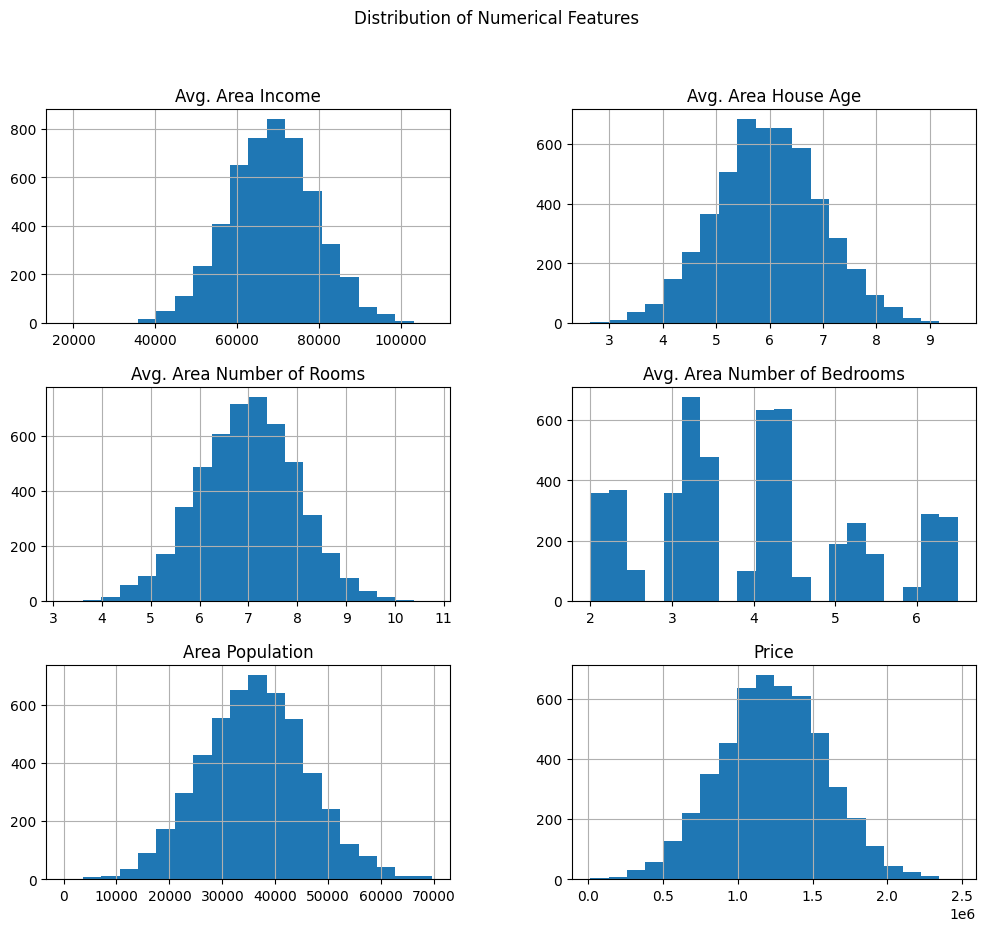

In [ ]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns

df[numerical_features].hist(figsize=(12,10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

**Correlation analysis**

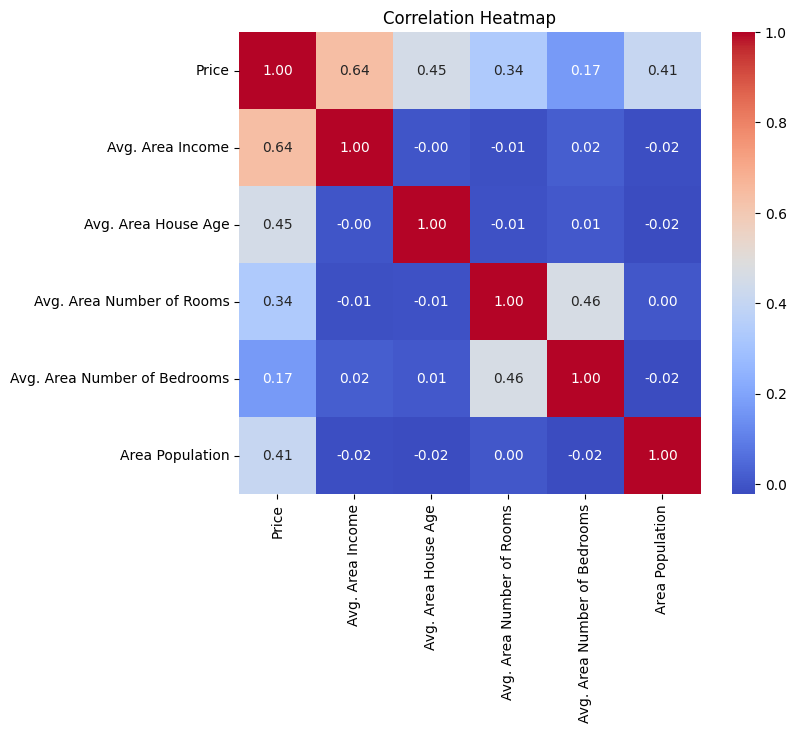

In [ ]:
numerical_cols = ['Price','Avg. Area Income',
    'Avg. Area House Age',
    'Avg. Area Number of Rooms',
    'Avg. Area Number of Bedrooms',
    'Area Population'
    ]
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

**Scatter plots**

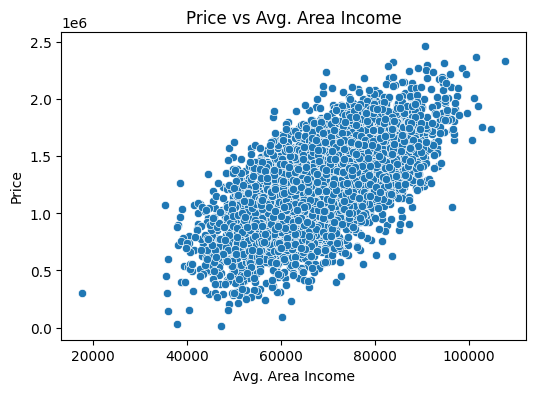

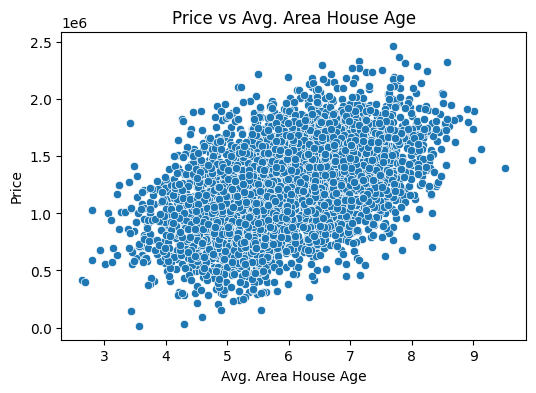

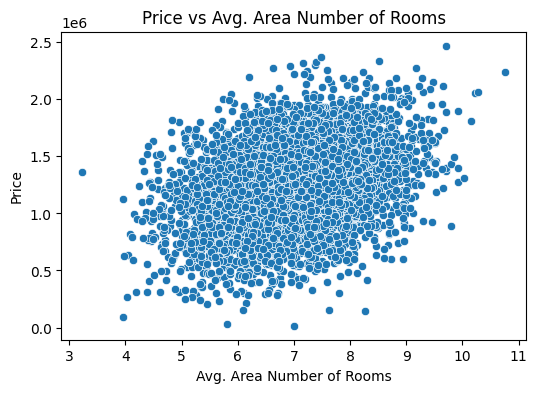

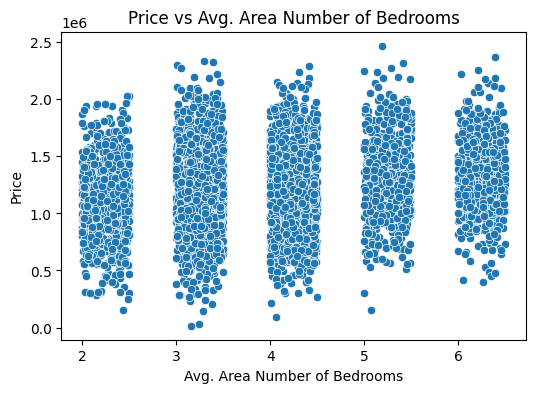

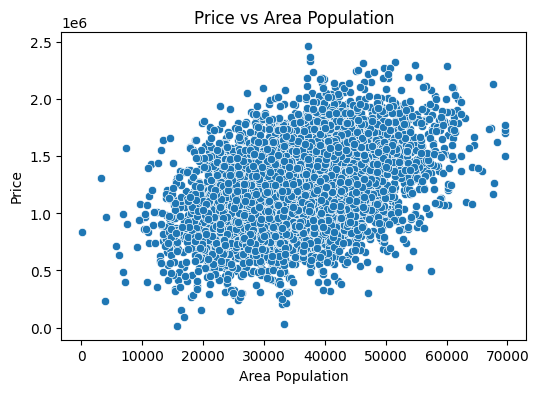

In [ ]:
features = [
    'Avg. Area Income',
    'Avg. Area House Age',
    'Avg. Area Number of Rooms',
    'Avg. Area Number of Bedrooms',
    'Area Population'
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df['Price'])
    plt.title(f"Price vs {feature}")
    plt.show()

**Key Findings**

1.Avg. Area Income has a strong positive correlation with Price, meaning houses in wealthier areas tend to have higher prices.

2.Avg. Area Number of Rooms also shows a positive relationship with house prices.

3.Area Population has a moderate correlation with price.

4.Avg. Area Number of Bedrooms has weaker correlation compared to number of rooms.

5.Address is not useful for prediction and will be dropped during modeling.

**Relationship Type**

Most relationships appear approximately linear, especially:

Price vs Income

Price vs Number of Rooms

In [ ]:
X = np.column_stack([
    df['Avg. Area Income'],
    df['Avg. Area House Age'],
    df['Avg. Area Number of Rooms'],
    df['Avg. Area Number of Bedrooms'],
    df['Area Population']
])

y = df['Price']

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (5000, 5)
y shape: (5000,)


KNN Regression

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Train: 4000 samples
Test: 1000 samples


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn_no_scale = KNeighborsRegressor(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)

print("WITHOUT Scaling:")
print(f"R² = {r2_score(y_test, y_pred_no_scale):.3f}")

WITHOUT Scaling:
R² = 0.485


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
y_pred_scaled = pipeline.predict(X_test)

print("WITH Scaling (Pipeline):")
print(f"R² = {r2_score(y_test, y_pred_scaled):.3f}")

WITH Scaling (Pipeline):
R² = 0.869


Choosing K

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 31)
train_errors = []
test_errors = []

for k in k_values:
    pipeline_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])
    pipeline_k.fit(X_train, y_train)

    train_errors.append(mean_squared_error(y_train, pipeline_k.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, pipeline_k.predict(X_test)))

In [ ]:
best_k = k_values[np.argmin(test_errors)]
print(f"Best K: {best_k}")
print(f"Best Test MSE: ${min(test_errors):,.0f}")

Best K: 9
Best Test MSE: $15,311,227,372


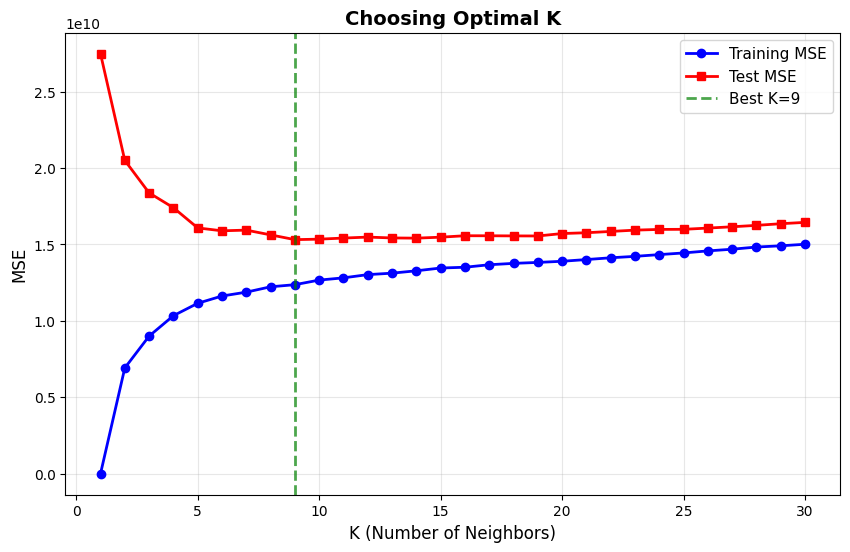

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, 'bo-', label='Training MSE', linewidth=2, markersize=6)
plt.plot(k_values, test_errors, 'rs-', label='Test MSE', linewidth=2, markersize=6)
plt.axvline(best_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Save and Load Model

In [ ]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

print(f"Trained final model with K={best_k}")
print(f"Test R²: {r2_score(y_test, final_pipeline.predict(X_test)):.3f}")

Trained final model with K=9
Test R²: 0.876


In [ ]:
import joblib

joblib.dump(final_pipeline, 'house_price_knn.pkl')

['house_price_knn.pkl']

In [ ]:
loaded_pipeline = joblib.load('house_price_knn.pkl')

In [ ]:
test_house = [[1500, 6, 3, 4, 6]]  # 1500 sqft, 3 bedrooms
prediction = loaded_pipeline.predict(test_house)[0]

print(f"Predicted Price: ${prediction:,.0f}")

Predicted Price: $525,669


Gradio Deployment
Build a web app with:

Input sliders for Square Feet, Bedrooms, K
Output: Predicted price + Visualization showing K neighbors

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def predict_house(income, house_age, rooms, bedrooms, population):
    prediction = loaded_pipeline.predict([[income, house_age, rooms, bedrooms, population]])[0]
    return f"${prediction:,.0f}"

interface = gr.Interface(
    fn=predict_house,
    inputs=[
        gr.Slider(20000, 100000, value=60000, label="Avg. Area Income"),
        gr.Slider(1, 10, value=5, label="Avg. Area House Age"),
        gr.Slider(1, 10, value=6, label="Avg. Area Number of Rooms"),
        gr.Slider(1, 6, value=3, step=1, label="Avg. Area Number of Bedrooms"),
        gr.Slider(10000, 70000, value=30000, label="Area Population")
    ],
    outputs=gr.Textbox(label="Predicted Price"),
    title="🏠 House Price Predictor"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e5a2c6bacfb3b3627f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def predict_and_visualize(income, house_age, rooms, bedrooms, population):

    X_new = np.array([[income, house_age, rooms, bedrooms, population]])
    prediction = loaded_pipeline.predict(X_new)[0]

    knn_model = loaded_pipeline.named_steps['knn']
    X_new_scaled = loaded_pipeline.named_steps['scaler'].transform(X_new)

    distances, indices = knn_model.kneighbors(X_new_scaled)
    neighbor_indices = indices[0]

    k = knn_model.n_neighbors

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot all houses (Rooms vs Bedrooms for visualization)
    ax.scatter(X_train[:, 2], X_train[:, 3],
               c='lightgray', s=100, alpha=0.5,
               edgecolors='gray', linewidth=0.5,
               label='Other Houses')

    # Plot nearest neighbors
    ax.scatter(X_train[neighbor_indices, 2], X_train[neighbor_indices, 3],
               c='lime', s=300, edgecolors='darkgreen', linewidth=2,
               label=f'{k} Nearest Neighbors', zorder=3)

    # Draw lines to neighbors
    for idx in neighbor_indices:
        ax.plot([rooms, X_train[idx, 2]],
                [bedrooms, X_train[idx, 3]],
                'g--', alpha=0.6, linewidth=2, zorder=2)

    # Plot new house
    ax.scatter([rooms], [bedrooms],
               c='red', s=800, marker='*',
               edgecolors='darkred', linewidth=3,
               label='Your House', zorder=5)

    ax.set_xlabel('Avg. Area Number of Rooms', fontsize=14, fontweight='bold')
    ax.set_ylabel('Avg. Area Number of Bedrooms', fontsize=14, fontweight='bold')

    ax.set_title(f'KNN Prediction: ${prediction:,.0f}',
                 fontsize=16, fontweight='bold', pad=20)

    ax.legend(loc='best', fontsize=12, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()

    return f"${prediction:,.0f}", fig

In [ ]:
interface = gr.Interface(
    fn=predict_and_visualize,
    inputs=[
        gr.Number(value=1500, label="Square Feet"),
        gr.Slider(1, 5, value=3, step=1, label="Bedrooms")
    ],
    outputs=[
        gr.Textbox(label="Predicted Price"),
        gr.Plot(label="KNN Visualization")
    ],
    title="🏠 House Price Predictor",
    description="Uses pre-trained KNN model"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc3bb811bebd0ea4a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
